Dataset Loaded Successfully
(34660, 21)

After Cleaning:
(34626, 2)

Sentiment Counts:
sentiment
Positive    32315
Neutral      1499
Negative      812
Name: count, dtype: int64


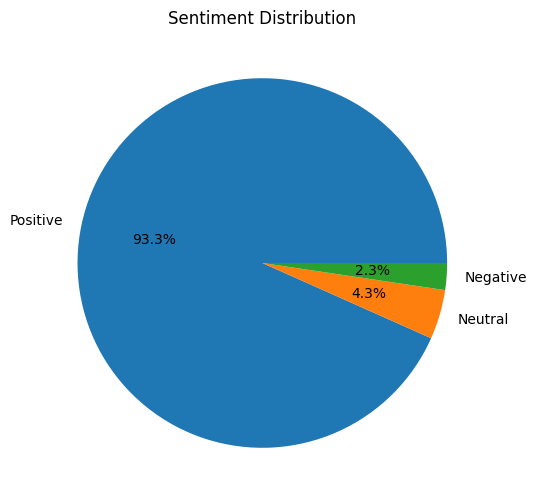


Accuracy:
93.99 %

Classification Report:

              precision    recall  f1-score   support

    Negative       0.56      0.13      0.21       157
     Neutral       0.49      0.08      0.13       278
    Positive       0.94      1.00      0.97      6491

    accuracy                           0.94      6926
   macro avg       0.66      0.40      0.44      6926
weighted avg       0.92      0.94      0.92      6926


Confusion Matrix:

[[  20   10  127]
 [   6   21  251]
 [  10   12 6469]]

File Saved:
predicted_reviews.csv


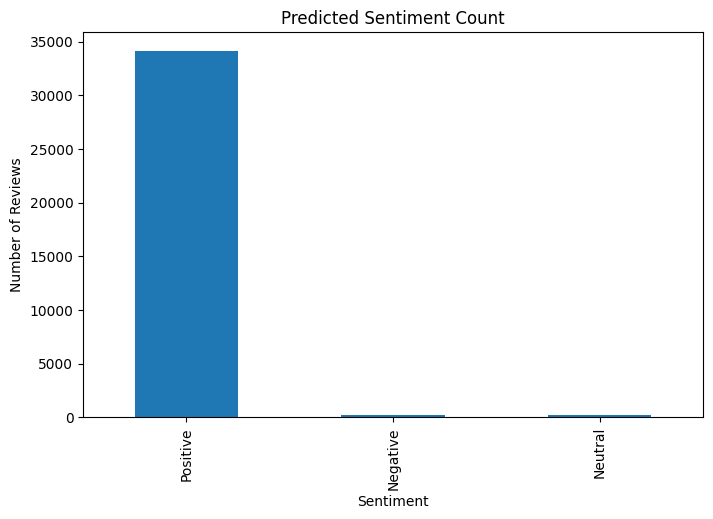


Sample Review:
Amazing product and very fast delivery
Predicted Sentiment:
Positive

Project Completed Successfully


In [7]:
# =====================================
# TRENDCART SENTIMENT ANALYSIS PROJECT
# =====================================

# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# =====================================
# Step 2: Load Dataset
# =====================================

df = pd.read_csv("1429_1.csv", low_memory=False)

print("Dataset Loaded Successfully")
print(df.shape)

# =====================================
# Step 3: Keep Required Columns
# =====================================

df = df[['reviews.text', 'reviews.rating']]

# Rename columns

df.columns = ['review', 'rating']

# =====================================
# Step 4: Remove Missing Values
# =====================================

df.dropna(inplace=True)

print("\nAfter Cleaning:")
print(df.shape)

# =====================================
# Step 5: Create Sentiment Labels
# =====================================

def get_sentiment(rating):

    if rating >= 4:
        return "Positive"

    elif rating == 3:
        return "Neutral"

    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(get_sentiment)

# =====================================
# Step 6: Sentiment Distribution
# =====================================

print("\nSentiment Counts:")
print(df['sentiment'].value_counts())

# =====================================
# Step 7: Pie Chart
# =====================================

plt.figure(figsize=(6,6))

df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Sentiment Distribution")
plt.ylabel("")

plt.show()

# =====================================
# Step 8: Feature and Label
# =====================================

X = df['review']
y = df['sentiment']

# =====================================
# Step 9: Train Test Split
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# =====================================
# Step 10: TF-IDF Vectorization
# =====================================

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

# =====================================
# Step 11: Train Logistic Regression
# =====================================

model = LogisticRegression(max_iter=1000)

model.fit(
    X_train_tfidf,
    y_train
)

# =====================================
# Step 12: Prediction
# =====================================

y_pred = model.predict(X_test_tfidf)

# =====================================
# Step 13: Accuracy
# =====================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(round(accuracy*100,2), "%")

# =====================================
# Step 14: Classification Report
# =====================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# =====================================
# Step 15: Confusion Matrix
# =====================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:\n")
print(cm)

# =====================================
# Step 16: Predict Entire Dataset
# =====================================

df['Predicted_Sentiment'] = model.predict(
    vectorizer.transform(df['review'])
)

# =====================================
# Step 17: Save Results
# =====================================

df.to_csv(
    "predicted_reviews.csv",
    index=False
)

print("\nFile Saved:")
print("predicted_reviews.csv")

# =====================================
# Step 18: Bar Graph
# =====================================

plt.figure(figsize=(8,5))

df['Predicted_Sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Predicted Sentiment Count")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

# =====================================
# Step 19: Sample Prediction
# =====================================

sample_review = [
    "Amazing product and very fast delivery"
]

sample_vector = vectorizer.transform(
    sample_review
)

prediction = model.predict(
    sample_vector
)

print("\nSample Review:")
print(sample_review[0])

print("Predicted Sentiment:")
print(prediction[0])

print("\nProject Completed Successfully")